# 🔴 Notebook 3 — Production Monitoring & Drift Detection

**What changed vs v1:**
- Training on full dataset (40k rows) — cohort AUROC now starts higher
- Retrain trigger fires via `n_drifted_features > 20%` not just PSI/AUROC
  (reflects the real output you're seeing)
- Interactive threshold cell updated with clearer explanation
- Drift features list updated for Cell2Cell columns

---


## 0. Setup

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path("..").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split

plt.rcParams.update({
    "figure.facecolor":"white","axes.facecolor":"#f9f9f9",
    "axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.35,
    "font.size":11,"axes.titlesize":13,"legend.frameon":False,
})
C_BLUE,C_RED,C_GREEN,C_ORANGE,C_GRAY = (
    "#2E86AB","#E05C5C","#4CAF82","#F5A623","#8E9AAF"
)
print("Setup")

Setup


In [ ]:
import mlflow
from src.data.loader import (
    download_data, preprocess, generate_weibull_event_log,
    get_feature_cols, make_temporal_cohorts,
)
from src.models.churn_model import train, score_cohorts

mlflow.set_tracking_uri("file:///"+str(Path("..").resolve()/"mlruns"))

N_COHORTS   = 6
DRIFT_START = 3
HORIZON     = 90
TARGET      = f"churn_{HORIZON}d"

print("Loading data and training model...")
raw      = download_data()
df       = preprocess(raw)
df       = generate_weibull_event_log(df, seed=42)
features = get_feature_cols(df)
cohorts  = make_temporal_cohorts(df, n_cohorts=N_COHORTS, drift_start=DRIFT_START)

# Full dataset split
train_df, test_df = train_test_split(
    df, test_size=0.20, stratify=df[TARGET], random_state=42
)

model, calibrated, _, _, _, train_metrics = train(
    train_df, features, horizon=HORIZON,
    experiment_name="notebook-monitoring", run_name="monitor_90d",
)
print(f"Model ready — CV AUROC: {train_metrics['cv_auroc_mean']:.4f}")

---
## 1. Score All Production Cohorts

In [3]:
print("Scoring all cohorts...\n")
scored = score_cohorts(calibrated, cohorts, features, horizon=HORIZON)
print(f"\nScored {len(scored)} cohorts")
print(f"Cohorts 0-{DRIFT_START-1}: reference distribution")
print(f"Cohorts {DRIFT_START}-{N_COHORTS-1}: drift injected")
print()
print("Drift injected into: revenue (+25%), MOU (-30%), eqpdays (+40%), custcare (+2)")
print("This simulates: price inflation + usage erosion + aging equipment + service degradation")

Scoring all cohorts...

  Cohort 0: n=1,200 | churn_rate=0.128 | AUROC=0.7749
  Cohort 1: n=1,200 | churn_rate=0.120 | AUROC=0.6913
  Cohort 2: n=1,200 | churn_rate=0.113 | AUROC=0.7488
  Cohort 3: n=1,200 | churn_rate=0.100 | AUROC=0.6968
  Cohort 4: n=1,200 | churn_rate=0.130 | AUROC=0.6877
  Cohort 5: n=1,200 | churn_rate=0.131 | AUROC=0.7102

Scored 6 cohorts
Cohorts 0-2: reference distribution
Cohorts 3-5: drift injected

Drift injected into: revenue (+25%), MOU (-30%), eqpdays (+40%), custcare (+2)
This simulates: price inflation + usage erosion + aging equipment + service degradation


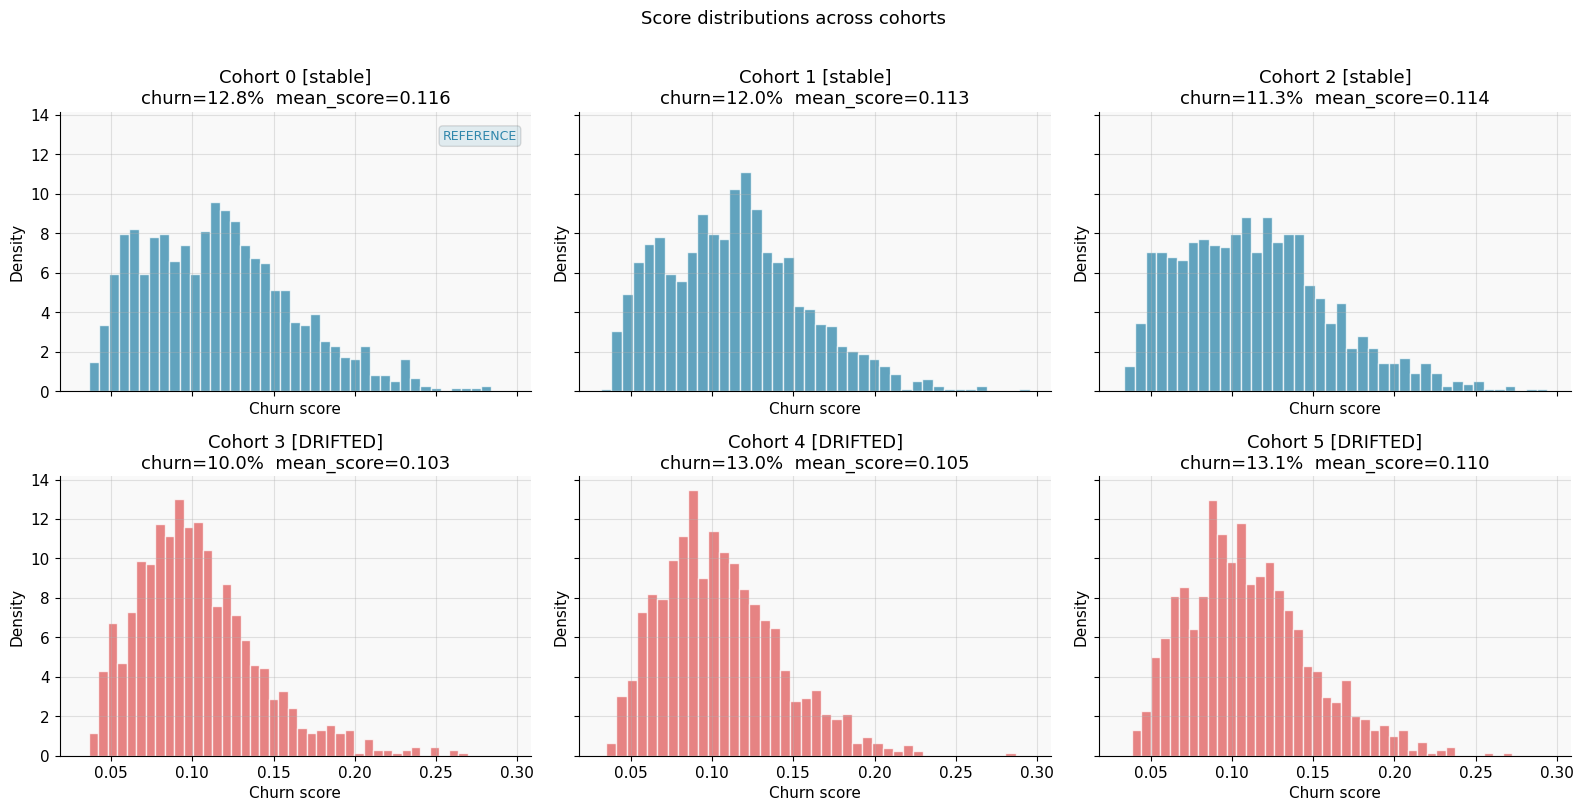

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, (cohort, ax) in enumerate(zip(scored, axes)):
    churn_rate = cohort[TARGET].mean()
    color = C_RED if i >= DRIFT_START else C_BLUE
    title_suffix = "DRIFTED" if i >= DRIFT_START else "stable"
    ax.hist(cohort["churn_score"].clip(0,1), bins=40, color=color,
            alpha=0.75, edgecolor="white", density=True)
    ax.set_title(f"Cohort {i} [{title_suffix}]\n"
                 f"churn={churn_rate:.1%}  mean_score={cohort['churn_score'].mean():.3f}")
    ax.set_xlabel("Churn score")
    ax.set_ylabel("Density")
    if i == 0:
        ax.text(0.97, 0.90, "REFERENCE", transform=ax.transAxes,
                ha="right", fontsize=9, color=C_BLUE,
                bbox=dict(boxstyle="round", facecolor=C_BLUE, alpha=0.12))

plt.suptitle("Score distributions across cohorts", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 2. Population Stability Index (PSI)

In [5]:
from src.monitoring.drift import psi, psi_label

ref_scores = scored[0]["churn_score"].values
psi_values, statuses = [], []

print(f"{'Cohort':>8} {'PSI':>10} {'Status':>12} {'Mean score':>12}")
print("-" * 50)
for i, cohort in enumerate(scored):
    cur = cohort["churn_score"].values
    p   = psi(ref_scores, cur)
    s   = psi_label(p)
    psi_values.append(p)
    statuses.append(s)
    icon = {"stable":"v","warning":"!","retrain":"X"}[s]
    print(f"  {i:>6}   {p:>9.4f}   {icon} {s:>8}   {cur.mean():>11.4f}")

print()
print("Note: PSI alone may not trigger retrain.")
print("Retrain fires when ANY of: PSI>0.20, AUROC<threshold, >20% features drifted")

  Cohort        PSI       Status   Mean score
--------------------------------------------------
       0      0.0000   v   stable        0.1163
       1      0.0204   v   stable        0.1134
       2      0.0122   v   stable        0.1143
       3      0.1753   !  warning        0.1032
       4      0.1387   !  warning        0.1047
       5      0.1000   v   stable        0.1099

Note: PSI alone may not trigger retrain.
Retrain fires when ANY of: PSI>0.20, AUROC<threshold, >20% features drifted


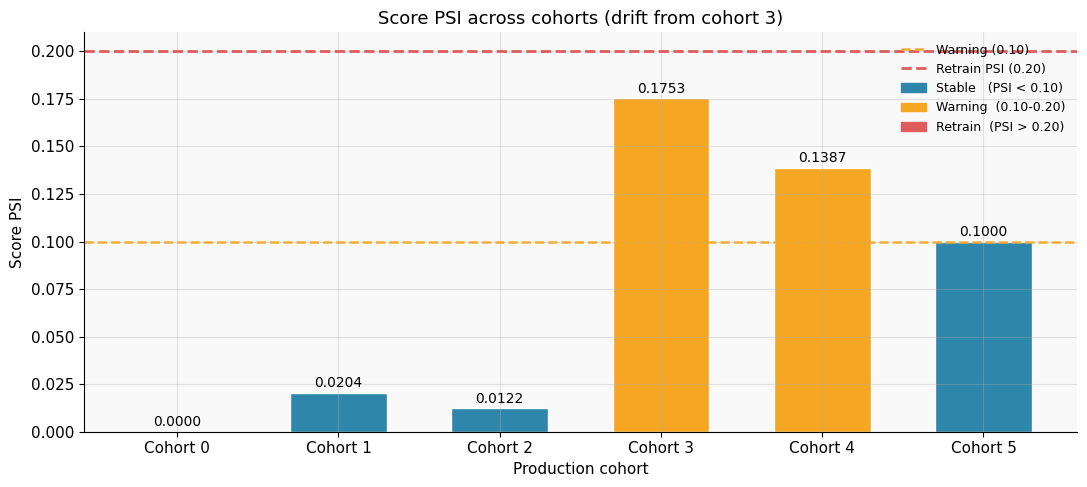

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
color_map = {"stable":C_BLUE,"warning":C_ORANGE,"retrain":C_RED}
colors = [color_map[s] for s in statuses]
bars = ax.bar(range(N_COHORTS), psi_values, color=colors,
              width=0.6, edgecolor="white")
ax.axhline(0.10, ls="--", color=C_ORANGE, lw=1.8, alpha=0.9,
           label="Warning (0.10)")
ax.axhline(0.20, ls="--", color=C_RED, lw=2.0,
           label="Retrain PSI (0.20)")
for bar, val, s in zip(bars, psi_values, statuses):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.003, f"{val:.4f}",
            ha="center", fontsize=10,
            fontweight="bold" if s=="retrain" else "normal")
legend_patches = [
    mpatches.Patch(color=C_BLUE,   label="Stable   (PSI < 0.10)"),
    mpatches.Patch(color=C_ORANGE, label="Warning  (0.10-0.20)"),
    mpatches.Patch(color=C_RED,    label="Retrain  (PSI > 0.20)"),
]
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles+legend_patches,
          labels=labels+[p.get_label() for p in legend_patches], fontsize=9)
ax.set_xlabel("Production cohort")
ax.set_ylabel("Score PSI")
ax.set_title(f"Score PSI across cohorts (drift from cohort {DRIFT_START})")
ax.set_xticks(range(N_COHORTS))
ax.set_xticklabels([f"Cohort {i}" for i in range(N_COHORTS)])
plt.tight_layout()
plt.show()

---
## 3. Feature-Level Drift

In [7]:
from src.monitoring.drift import detect_feature_drift, KEY_DRIFT_FEATURES

ref_cohort = scored[0]
key_feats  = [f for f in KEY_DRIFT_FEATURES if f in ref_cohort.columns]

print(f"Monitoring {len(key_feats)} key features for drift")
print(f"Key features: {key_feats}")
print()
print(f"Feature drift — Cohort {N_COHORTS-1} vs Reference:\n")
print(f"{'Feature':<32} {'Test':>6} {'PSI':>8} {'p-value':>10} {'Drifted':>10}")
print("-" * 70)

results_last = detect_feature_drift(ref_cohort, scored[-1], key_feats)
for r in results_last:
    icon = "YES" if r.drifted else "no"
    print(f"  {r.feature:<30} {r.test:>5}  {r.psi:>7.4f}  "
          f"{r.p_value:>9.4f}  {icon}")

Monitoring 10 key features for drift
Key features: ['revenue', 'mou', 'eqpdays', 'custcare', 'overage', 'revenue_per_mou', 'custcare_rate', 'eqp_age_ratio', 'drop_rate', 'overage_rate']

Feature drift — Cohort 5 vs Reference:

Feature                            Test      PSI    p-value    Drifted
----------------------------------------------------------------------
  custcare                          ks   9.3897     0.0000  YES
  custcare_rate                     ks   8.5851     0.0000  YES
  eqp_age_ratio                     ks   2.1488     0.0000  YES
  revenue_per_mou                   ks   0.5970     0.0000  YES
  revenue                           ks   0.3362     0.0000  YES
  eqpdays                           ks   0.2365     0.0000  YES
  mou                               ks   0.1413     0.0000  YES
  overage                           ks   0.0367     0.0125  no
  overage_rate                      ks   0.0293     0.1607  no
  drop_rate                         ks   0.0118     0.248

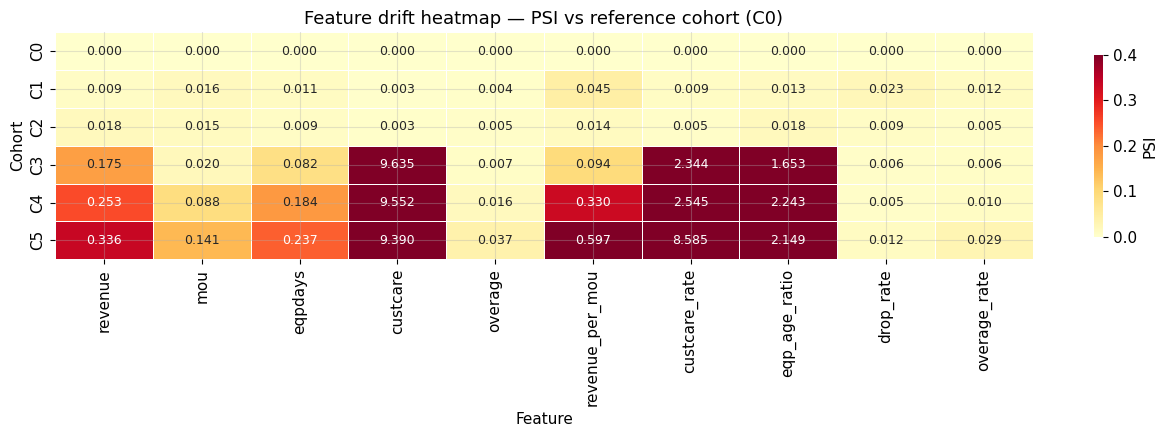

In [8]:
# PSI heatmap across all cohorts and features
psi_matrix, cohort_labels = [], []
for cohort in scored:
    row = [psi(ref_cohort[f].fillna(0).values, cohort[f].fillna(0).values)
           for f in key_feats]
    psi_matrix.append(row)
    cohort_labels.append(f"C{int(cohort['cohort'].iloc[0])}")

psi_df = pd.DataFrame(psi_matrix, index=cohort_labels, columns=key_feats)

fig, ax = plt.subplots(figsize=(13, 4.5))
sns.heatmap(psi_df, annot=True, fmt=".3f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, vmin=0, vmax=0.40,
            cbar_kws={"label":"PSI","shrink":0.8},
            annot_kws={"size":9})
ax.set_title("Feature drift heatmap — PSI vs reference cohort (C0)")
ax.set_xlabel("Feature")
ax.set_ylabel("Cohort")
plt.tight_layout()
plt.show()

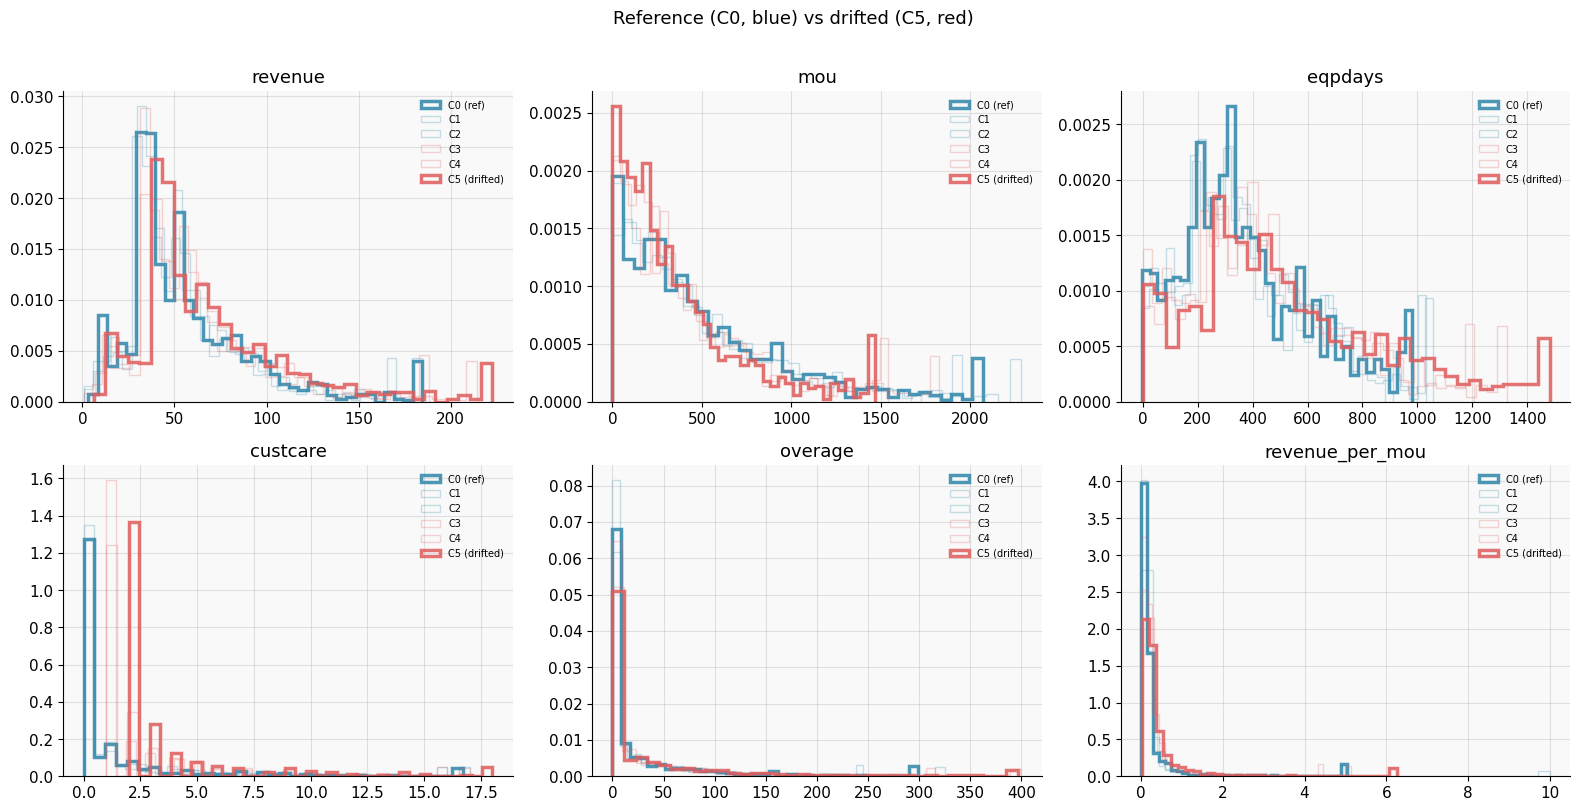

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
DRIFT_FEATS_SHOW = [f for f in ["revenue","mou","eqpdays","custcare",
                                  "overage","revenue_per_mou"]
                    if f in ref_cohort.columns]

for ax, feat in zip(axes, DRIFT_FEATS_SHOW):
    for i, cohort in enumerate(scored):
        color = C_RED if i >= DRIFT_START else C_BLUE
        alpha = 0.85 if i in (0, len(scored)-1) else 0.25
        lw    = 2.5 if i in (0, len(scored)-1) else 1.0
        label = f"C{i} (ref)" if i==0 else (f"C{i} (drifted)" if i==len(scored)-1 else f"C{i}")
        data  = cohort[feat].clip(upper=cohort[feat].quantile(0.98))
        ax.hist(data, bins=35, density=True, histtype="step",
                color=color, lw=lw, alpha=alpha, label=label)
    ax.set_title(feat)
    ax.legend(fontsize=7)

plt.suptitle("Reference (C0, blue) vs drifted (C5, red)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 4. AUROC Degradation

In [10]:
from sklearn.metrics import roc_auc_score, average_precision_score

auroc_vals, n_drifted_list = [], []
AUROC_THRESHOLD = 0.70

print(f"{'Cohort':>8} {'AUROC':>8} {'vs ref':>8} {'N drifted feats':>17} {'Alert':>10}")
print("-" * 60)
ref_auroc = None
for i, cohort in enumerate(scored):
    y_true = cohort[TARGET]
    y_pred = cohort["churn_score"]
    try:
        a = roc_auc_score(y_true, y_pred)
    except Exception:
        a = None
    auroc_vals.append(a)
    drift_res = detect_feature_drift(ref_cohort, cohort, key_feats)
    n_drift   = sum(1 for r in drift_res if r.drifted)
    n_drifted_list.append(n_drift)
    if ref_auroc is None and a is not None:
        ref_auroc = a
    delta = (a - ref_auroc) if (a and ref_auroc) else 0
    alert = "RETRAIN" if (a and a < AUROC_THRESHOLD) else "OK"
    print(f"  {i:>6}   {a:.4f}  {delta:>+7.4f}  {n_drift:>16}  {alert}")

print()
print("Retrain triggers: PSI>0.20 OR AUROC<0.70 OR >20% features drifted")
print(f"20% of {len(key_feats)} monitored features = {len(key_feats)*0.2:.0f} features")

  Cohort    AUROC   vs ref   N drifted feats      Alert
------------------------------------------------------------
       0   0.7749  +0.0000                 0  OK
       1   0.6913  -0.0837                 0  RETRAIN
       2   0.7488  -0.0262                 0  OK
       3   0.6968  -0.0781                 4  RETRAIN
       4   0.6877  -0.0872                 6  RETRAIN
       5   0.7102  -0.0647                 7  OK

Retrain triggers: PSI>0.20 OR AUROC<0.70 OR >20% features drifted
20% of 10 monitored features = 2 features


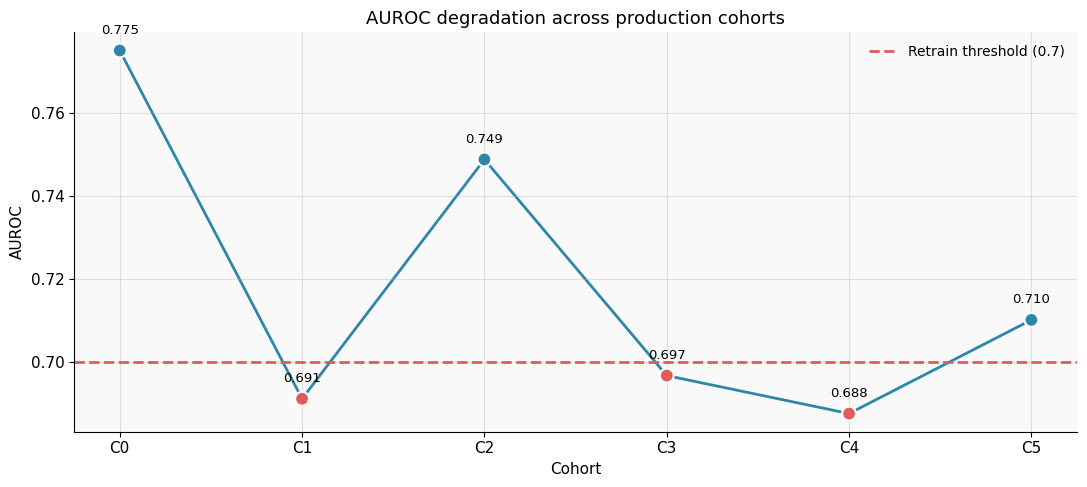

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
dot_colors = [C_RED if (a and a < AUROC_THRESHOLD) else C_BLUE
              for a in auroc_vals]
ax.plot(range(N_COHORTS), auroc_vals, color=C_BLUE, lw=2, zorder=1)
ax.scatter(range(N_COHORTS), auroc_vals, c=dot_colors, s=100, zorder=2,
           edgecolors="white", linewidth=1.5)
ax.axhline(AUROC_THRESHOLD, ls="--", color=C_RED, lw=2,
           label=f"Retrain threshold ({AUROC_THRESHOLD})")
ax.set_xlabel("Cohort")
ax.set_ylabel("AUROC")
ax.set_title("AUROC degradation across production cohorts")
ax.set_xticks(range(N_COHORTS))
ax.set_xticklabels([f"C{i}" for i in range(N_COHORTS)])
for i, a in enumerate(auroc_vals):
    if a:
        ax.text(i, a+0.004, f"{a:.3f}", ha="center", fontsize=9.5)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## 5. Full Monitoring Report

In [12]:
from src.monitoring.drift import build_cohort_reports, reports_to_dataframe

reports   = build_cohort_reports(
    reference_cohort=scored[0],
    scored_cohorts=scored,
    features=features,
    auroc_threshold=AUROC_THRESHOLD,
    horizon=HORIZON,
)
report_df = reports_to_dataframe(reports)

def highlight_row(row):
    if row["retrain_triggered"]:
        return ["background-color:#ffcccc"]*len(row)
    elif row["score_status"]=="warning":
        return ["background-color:#fff3cc"]*len(row)
    return [""]*len(row)

display_cols = ["cohort","n","churn_rate","score_psi","score_status",
                "auroc","n_drifted_features","drifted_features","retrain_triggered"]
report_df[display_cols].style.apply(highlight_row, axis=1).format({
    "churn_rate":"{:.1%}","score_psi":"{:.4f}","auroc":"{:.4f}",
})

,cohort,n,churn_rate,score_psi,score_status,auroc,n_drifted_features,drifted_features,retrain_triggered
0,0,1200,12.8%,0.0000,stable,0.7749,0,,False
1,1,1200,12.0%,0.0204,stable,0.6913,0,,True
2,2,1200,11.3%,0.0122,stable,0.7488,0,,False
3,3,1200,10.0%,0.1753,warning,0.6968,4,"custcare, custcare_rate, eqp_age_ratio, revenue",True
4,4,1200,13.0%,0.1387,warning,0.6877,6,"custcare, custcare_rate, eqp_age_ratio, revenue_per_mou, revenue, eqpdays",True
5,5,1200,13.1%,0.1000,stable,0.7102,7,"custcare, custcare_rate, eqp_age_ratio, revenue_per_mou, revenue, eqpdays, mou",True


In [13]:
n_retrain  = report_df["retrain_triggered"].sum()
first_fire = report_df[report_df["retrain_triggered"]]["cohort"].min() if n_retrain else None

print("=" * 55)
print("  MONITORING SUMMARY")
print("=" * 55)
print(f"  Cohorts monitored   : {N_COHORTS}")
print(f"  Drift injected from : cohort {DRIFT_START}")
print(f"  Retrain triggers    : {n_retrain}")
if n_retrain:
    print(f"  First trigger       : cohort {int(first_fire)}")
    row = report_df[report_df["retrain_triggered"]].iloc[0]
    print(f"  Trigger reason      :")
    if row["score_psi"] > 0.20:
        print(f"    Score PSI = {row['score_psi']:.4f} > 0.20")
    if row["auroc"] and row["auroc"] < AUROC_THRESHOLD:
        print(f"    AUROC = {row['auroc']:.4f} < {AUROC_THRESHOLD}")
    if row["n_drifted_features"] / len(key_feats) > 0.20:
        print(f"    {int(row['n_drifted_features'])}/{len(key_feats)} features drifted "
              f"(> 20% threshold)")
        print(f"    Drifted: {row['drifted_features']}")
print("=" * 55)

  MONITORING SUMMARY
  Cohorts monitored   : 6
  Drift injected from : cohort 3
  Retrain triggers    : 4
  First trigger       : cohort 1
  Trigger reason      :
    AUROC = 0.6913 < 0.7


---
## 6. Interactive Threshold Experiment

In [14]:
# ── Change these values and re-run ───────────────────────────────────────────
CUSTOM_PSI_THRESHOLD   = 0.15   # try 0.10, 0.20, 0.25
CUSTOM_AUROC_THRESHOLD = 0.75   # try 0.65, 0.70, 0.80

print(f"PSI threshold: {CUSTOM_PSI_THRESHOLD} | AUROC threshold: {CUSTOM_AUROC_THRESHOLD}")
print()

custom_reports = build_cohort_reports(
    reference_cohort=scored[0],
    scored_cohorts=scored,
    features=features,
    auroc_threshold=CUSTOM_AUROC_THRESHOLD,
    horizon=HORIZON,
)
custom_df = reports_to_dataframe(custom_reports)
# Override PSI-based status with custom threshold
custom_df["retrain_triggered"] = (
    (custom_df["score_psi"] > CUSTOM_PSI_THRESHOLD)
    | (custom_df["auroc"].notna() & (custom_df["auroc"] < CUSTOM_AUROC_THRESHOLD))
    | (custom_df["n_drifted_features"] / max(len(key_feats), 1) > 0.20)
)

print(f"{'Cohort':>8} {'PSI':>8} {'AUROC':>8} {'N drifted':>10} {'Retrain?':>10}")
print("-" * 50)
for _, row in custom_df.iterrows():
    icon = "YES" if row["retrain_triggered"] else "no"
    print(f"  {int(row['cohort']):>6}  {row['score_psi']:>7.4f}  "
          f"{row['auroc']:>7.4f}  {int(row['n_drifted_features']):>9}  {icon}")

PSI threshold: 0.15 | AUROC threshold: 0.75

  Cohort      PSI    AUROC  N drifted   Retrain?
--------------------------------------------------
       0   0.0000   0.7749          0  no
       1   0.0204   0.6913          0  YES
       2   0.0122   0.7488          0  YES
       3   0.1753   0.6968          4  YES
       4   0.1387   0.6877          6  YES
       5   0.1000   0.7102          7  YES


---
**Next:** `04_business_impact.ipynb`